# Network Validation & Slack Analysis

Check network data integrity and investigate slack generator usage.

In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NETWORK_PATH = "../scenarios/baseline_networks/bat1x_gas18_co2_40_cy2003.nc"

n = pypsa.Network()
n.import_from_netcdf(NETWORK_PATH)
print(f"Loaded: {NETWORK_PATH}")
print(f"Buses: {len(n.buses)}, Generators: {len(n.generators)}, Loads: {len(n.loads)}, Links: {len(n.links)}")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


Loaded: ../scenarios/baseline_networks/bat1x_gas18_co2_40_cy2003.nc
Buses: 55, Generators: 557, Loads: 52, Links: 209


## 1. Slack Usage — Which Buses and When

In [3]:
slack_gens = n.generators[n.generators.carrier == "slack"]
print(f"Slack generators: {len(slack_gens)}")

if len(slack_gens) > 0 and len(n.generators_t.p.columns) > 0:
    slack_cols = slack_gens.index.intersection(n.generators_t.p.columns)
    slack_p = n.generators_t.p[slack_cols]
    
    slack_by_bus = slack_p.sum().rename(lambda x: x.replace("-slack", ""))
    slack_by_bus = slack_by_bus[slack_by_bus > 0].sort_values(ascending=False)
    
    total_slack_gwh = slack_p.sum().sum() / 1e3
    print(f"\nTotal slack: {total_slack_gwh:.1f} GWh")
    print(f"\nTop 15 buses by slack usage (MWh):")
    print(slack_by_bus.head(15).to_string())
else:
    print("No slack dispatched.")

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)

Slack generators: 55

Total slack: 376.7 GWh

Top 15 buses by slack usage (MWh):
name
DE00    341846.706272
LUG1     19632.046930
MT00      8993.818724
FR15      6002.547696
DKE1       169.030187
DKW1       105.256439


Hours with slack > 1 MW: 477 / 8760 (5.4%)
Max slack in single hour: 20481 MW
Peak slack hour: 2030-01-31 17:00:00


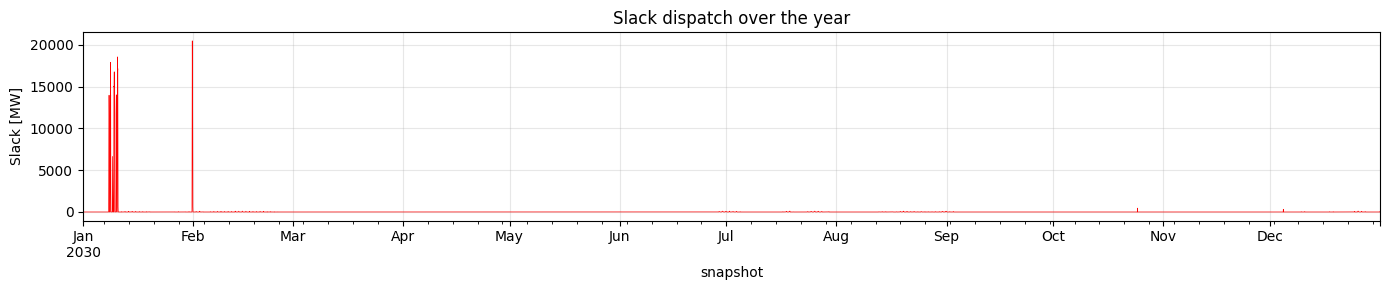

In [4]:
# Slack over time — how many hours and when
if len(slack_gens) > 0:
    slack_cols = slack_gens.index.intersection(n.generators_t.p.columns)
    slack_total_per_hour = n.generators_t.p[slack_cols].sum(axis=1)
    slack_hours = (slack_total_per_hour > 1).sum()
    
    print(f"Hours with slack > 1 MW: {slack_hours} / 8760 ({100*slack_hours/8760:.1f}%)")
    print(f"Max slack in single hour: {slack_total_per_hour.max():.0f} MW")
    print(f"Peak slack hour: {slack_total_per_hour.idxmax()}")
    
    fig, ax = plt.subplots(figsize=(14, 3))
    slack_total_per_hour.plot(ax=ax, linewidth=0.5, color="red")
    ax.set_ylabel("Slack [MW]")
    ax.set_title("Slack dispatch over the year")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 2. Data Integrity — Generators with Missing Time Series

In [5]:
# Carriers that should have p_max_pu time series
VARIABLE_CARRIERS = {"onwind", "offwind", "solar-pv-utility", "solar-pv-rooftop", "nuclear", "hydro-ror"}

variable_gens = n.generators[n.generators.carrier.isin(VARIABLE_CARRIERS)]
has_ts = variable_gens.index.isin(n.generators_t.p_max_pu.columns)

missing = variable_gens[~has_ts]
present = variable_gens[has_ts]

print(f"Variable generators: {len(variable_gens)}")
print(f"  With p_max_pu time series: {has_ts.sum()}")
print(f"  MISSING p_max_pu time series: {(~has_ts).sum()}")

if len(missing) > 0:
    print("\nMissing time series by carrier:")
    print(missing.groupby("carrier").size().to_string())
    print("\nMissing generators:")
    print(missing[["bus", "carrier", "p_nom"]].to_string())

Variable generators: 202
  With p_max_pu time series: 201
  MISSING p_max_pu time series: 1

Missing time series by carrier:
carrier
hydro-ror    1

Missing generators:
                         bus    carrier  p_nom
name                                          
FR15-hydro-ror-turbine  FR15  hydro-ror   14.0


In [6]:
# Check p_max_pu values — any NaN or out of range?
p_max_pu = n.generators_t.p_max_pu
print(f"p_max_pu time series shape: {p_max_pu.shape}")

nan_count = p_max_pu.isna().sum().sum()
out_of_range = ((p_max_pu < 0) | (p_max_pu > 1)).sum().sum()
all_zero = (p_max_pu == 0).all(axis=0).sum()

print(f"NaN values: {nan_count}")
print(f"Values out of [0,1]: {out_of_range}")
print(f"Generators with p_max_pu = 0 for entire year: {all_zero}")

if all_zero > 0:
    zero_gens = p_max_pu.columns[(p_max_pu == 0).all(axis=0)]
    print("\nGenerators always at zero:")
    print(n.generators.loc[zero_gens, ["bus", "carrier", "p_nom"]].to_string())

p_max_pu time series shape: (8760, 250)
NaN values: 0
Values out of [0,1]: 10800
Generators with p_max_pu = 0 for entire year: 1

Generators always at zero:
                         bus    carrier  p_nom
name                                          
ITS1-hydro-ror-turbine  ITS1  hydro-ror  50.03


## 3. Load Data Integrity

In [7]:
# Check that all loads have time series
loads_with_ts = n.loads.index.isin(n.loads_t.p_set.columns)
print(f"Loads: {len(n.loads)}")
print(f"  With p_set time series: {loads_with_ts.sum()}")
print(f"  MISSING p_set time series: {(~loads_with_ts).sum()}")

if (~loads_with_ts).any():
    print("\nLoads without time series (using p_set static):")
    print(n.loads[~loads_with_ts][["bus", "p_set"]].to_string())

# Check for zero/NaN loads
p_set = n.loads_t.p_set
zero_loads = (p_set == 0).all(axis=0)
nan_loads = p_set.isna().any(axis=0)
print(f"\nLoads with all-zero demand: {zero_loads.sum()}")
print(f"Loads with any NaN: {nan_loads.sum()}")

print(f"\nTotal annual demand: {p_set.sum().sum()/1e6:.1f} TWh")
print(f"Peak demand: {p_set.sum(axis=1).max()/1e3:.1f} GW")

Loads: 52
  With p_set time series: 52
  MISSING p_set time series: 0

Loads with all-zero demand: 0
Loads with any NaN: 0

Total annual demand: 3978.7 TWh
Peak demand: 693.5 GW


## 4. Generation Capacity vs Demand — Bus-Level Balance

In [8]:
# For each bus: peak demand vs installed capacity (p_nom)
peak_demand = n.loads_t.p_set.groupby(n.loads.bus, axis=1).sum().max()

# Total p_nom per bus (excluding slack)
non_slack = n.generators[n.generators.carrier != "slack"]
installed_cap = non_slack.groupby("bus")["p_nom"].sum()

# Also include storage
storage_cap = n.storage_units.groupby("bus")["p_nom"].sum() if len(n.storage_units) > 0 else pd.Series(dtype=float)

balance = pd.DataFrame({
    "peak_demand_MW": peak_demand,
    "gen_capacity_MW": installed_cap,
    "storage_MW": storage_cap,
}).fillna(0)
balance["total_capacity_MW"] = balance["gen_capacity_MW"] + balance["storage_MW"]
balance["ratio"] = balance["total_capacity_MW"] / balance["peak_demand_MW"]

print("Buses with capacity ratio < 0.5 (potentially underserved):")
underserved = balance[balance["ratio"] < 0.5].sort_values("ratio")
if len(underserved) > 0:
    print(underserved.to_string())
else:
    print("None — all buses have capacity >= 50% of peak demand.")

print(f"\nFull balance table:")
print(balance.sort_values("ratio").to_string())

Buses with capacity ratio < 0.5 (potentially underserved):
      peak_demand_MW  gen_capacity_MW  storage_MW  total_capacity_MW  ratio
bus                                                                        
LUB1       95.195695              0.0         0.0                0.0    0.0
LUF1      191.247862              0.0         0.0                0.0    0.0

Full balance table:
      peak_demand_MW  gen_capacity_MW    storage_MW  total_capacity_MW     ratio
bus                                                                             
LUB1       95.195695         0.000000      0.000000           0.000000  0.000000
LUF1      191.247862         0.000000      0.000000           0.000000  0.000000
MT00      849.897331       758.879313      0.000000         758.879313  0.892907
SE04     4845.461538      5901.817454    307.639631        6209.457085  1.281500
SE03    16898.293924     19411.570505   2447.723074       21859.293580  1.293580
LUG1     1307.328087      1942.300000     25.0000

/var/folders/kr/02s80h4x0pn0rxjq93w2tjz00000gn/T/ipykernel_89186/1236217957.py:2: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



## 5. Buses with Largest Slack — Deep Dive

In [9]:
# Pick the worst bus and show its generation mix vs demand
if len(slack_by_bus) > 0:
    worst_bus = slack_by_bus.index[0]
    print(f"Worst bus: {worst_bus}  ({slack_by_bus.iloc[0]/1e3:.1f} GWh slack)")
    
    # Generators at this bus
    bus_gens = n.generators[n.generators.bus == worst_bus]
    print(f"\nGenerators at {worst_bus}:")
    print(bus_gens[["carrier", "p_nom", "marginal_cost"]].to_string())
    
    # Demand at this bus
    bus_loads = n.loads[n.loads.bus == worst_bus].index
    if len(bus_loads) > 0 and bus_loads[0] in n.loads_t.p_set.columns:
        bus_demand = n.loads_t.p_set[bus_loads].sum(axis=1)
        print(f"\nAnnual demand: {bus_demand.sum()/1e6:.2f} TWh")
        print(f"Peak demand:   {bus_demand.max():.0f} MW")
    
    # Links (import/export) connected to this bus
    links_from = n.links[n.links.bus0 == worst_bus]
    links_to = n.links[n.links.bus1 == worst_bus]
    print(f"\nLinks from {worst_bus}: {len(links_from)}")
    print(f"Links to   {worst_bus}: {len(links_to)}")
    if len(links_from) > 0:
        print(links_from[["bus1", "p_nom"]].to_string())
    if len(links_to) > 0:
        print(links_to[["bus0", "p_nom"]].to_string())

Worst bus: DE00  (341.8 GWh slack)

Generators at DE00:
                                                         carrier         p_nom  marginal_cost
name                                                                                         
DE00-gas-ccgt                                                gas  2.224586e+04      48.282569
DE00-gas-conv                                                gas  1.054767e+03      48.282569
DE00-gas-ocgt                                                gas  2.399106e+03      66.776829
DE00-oil-light                                         oil-light  1.585330e+03     158.783586
DE00-hydro-ror-turbine                                 hydro-ror  3.933900e+03       0.000000
DE00-onwind                                               onwind  1.150007e+05       1.428600
DE00-offwind                                             offwind  3.052130e+04       0.021200
DE00-solar-pv-utility                           solar-pv-utility  9.700200e+04       0.010600
DE00

## 6. Summary

In [10]:
print("=" * 60)
print("NETWORK VALIDATION SUMMARY")
print("=" * 60)
print(f"Network:          {NETWORK_PATH.split('/')[-1]}")
print(f"Buses:            {len(n.buses)}")
print(f"Generators:       {len(n.generators)}  (incl. slack: {len(slack_gens)})")
print(f"Loads:            {len(n.loads)}")
print(f"Links (NTC):      {len(n.links)}")
print(f"Storage units:    {len(n.storage_units)}")
print()
print(f"Total slack:      {slack_p.sum().sum()/1e3:.1f} GWh  ({100*slack_p.sum().sum()/n.loads_t.p_set.sum().sum():.3f}% of demand)")
print(f"Generators missing p_max_pu: {(~has_ts).sum()}")
print(f"Loads missing p_set:         {(~loads_with_ts).sum()}")
print(f"NaN in p_max_pu:             {nan_count}")

NETWORK VALIDATION SUMMARY
Network:          bat1x_gas18_co2_40_cy2003.nc
Buses:            55
Generators:       557  (incl. slack: 55)
Loads:            52
Links (NTC):      209
Storage units:    119

Total slack:      376.7 GWh  (0.009% of demand)
Generators missing p_max_pu: 1
Loads missing p_set:         0
NaN in p_max_pu:             0
